# STEP 5: Model Explainability — SHAP + LIME

In [3]:
!pip install shap

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---

In [5]:
!pip install lime

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283839 sha256=1e5e05388c93ebe23bd1bb96c02a027154ab715aa4bcb8aaec5936b5f96918a1
  Stored in directory: c:\users\xpristo\appdata\local\pip\cache\wheels\7c\04\5c\157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built lime


  DEPRECATION: Building 'lime' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'lime'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [6]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import shap
from lime.lime_text import LimeTextExplainer

In [7]:
# LOAD CLASSICAL MODEL FOR EXPLAINABILITY
# (SHAP and LIME work seamlessly with sklearn pipelines)
pipeline = joblib.load(r'C:\Users\XPRISTO\Desktop\NLP\tuned_lr_model.pkl')
le       = joblib.load(r'C:\Users\XPRISTO\Desktop\NLP\label_encoder.pkl')

test = pd.read_csv(r'C:\Users\XPRISTO\Desktop\NLP\test.csv')
X_test = test['clean_text'].values
y_test = test['label'].values

In [8]:
# 1. SHAP — GLOBAL FEATURE IMPORTANCE
print("Computing SHAP values (this may take a minute)...")

# Extract TF-IDF step from pipeline
tfidf_step = pipeline.named_steps['tfidf']
clf_step   = pipeline.named_steps['clf']

X_test_tfidf = tfidf_step.transform(X_test[:500])   # use 500 samples for speed

explainer    = shap.LinearExplainer(clf_step, X_test_tfidf, feature_perturbation='interventional')
shap_values  = explainer.shap_values(X_test_tfidf)

feature_names = tfidf_step.get_feature_names_out()

Computing SHAP values (this may take a minute)...


C:\Users\XPRISTO\anaconda3\Lib\site-packages\shap\explainers\_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


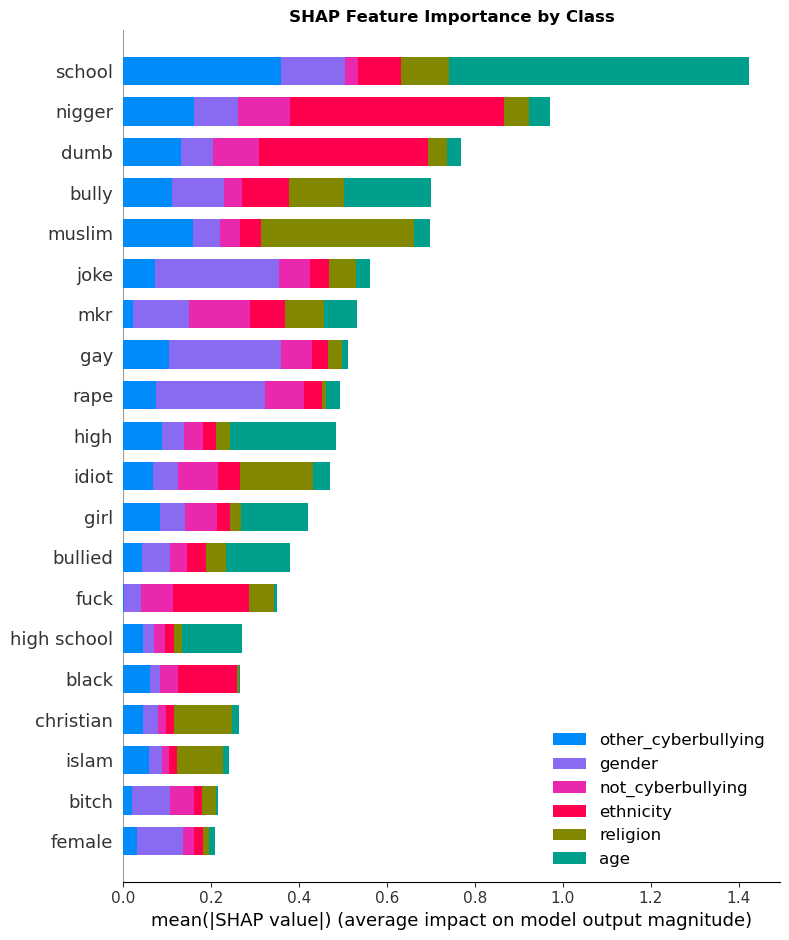

Saved: shap_summary.png


In [10]:
# Summary plot (top features per class)
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test_tfidf,
    feature_names=feature_names,
    class_names=le.classes_,
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance by Class', fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\XPRISTO\Desktop\NLP\shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved: shap_summary.png")

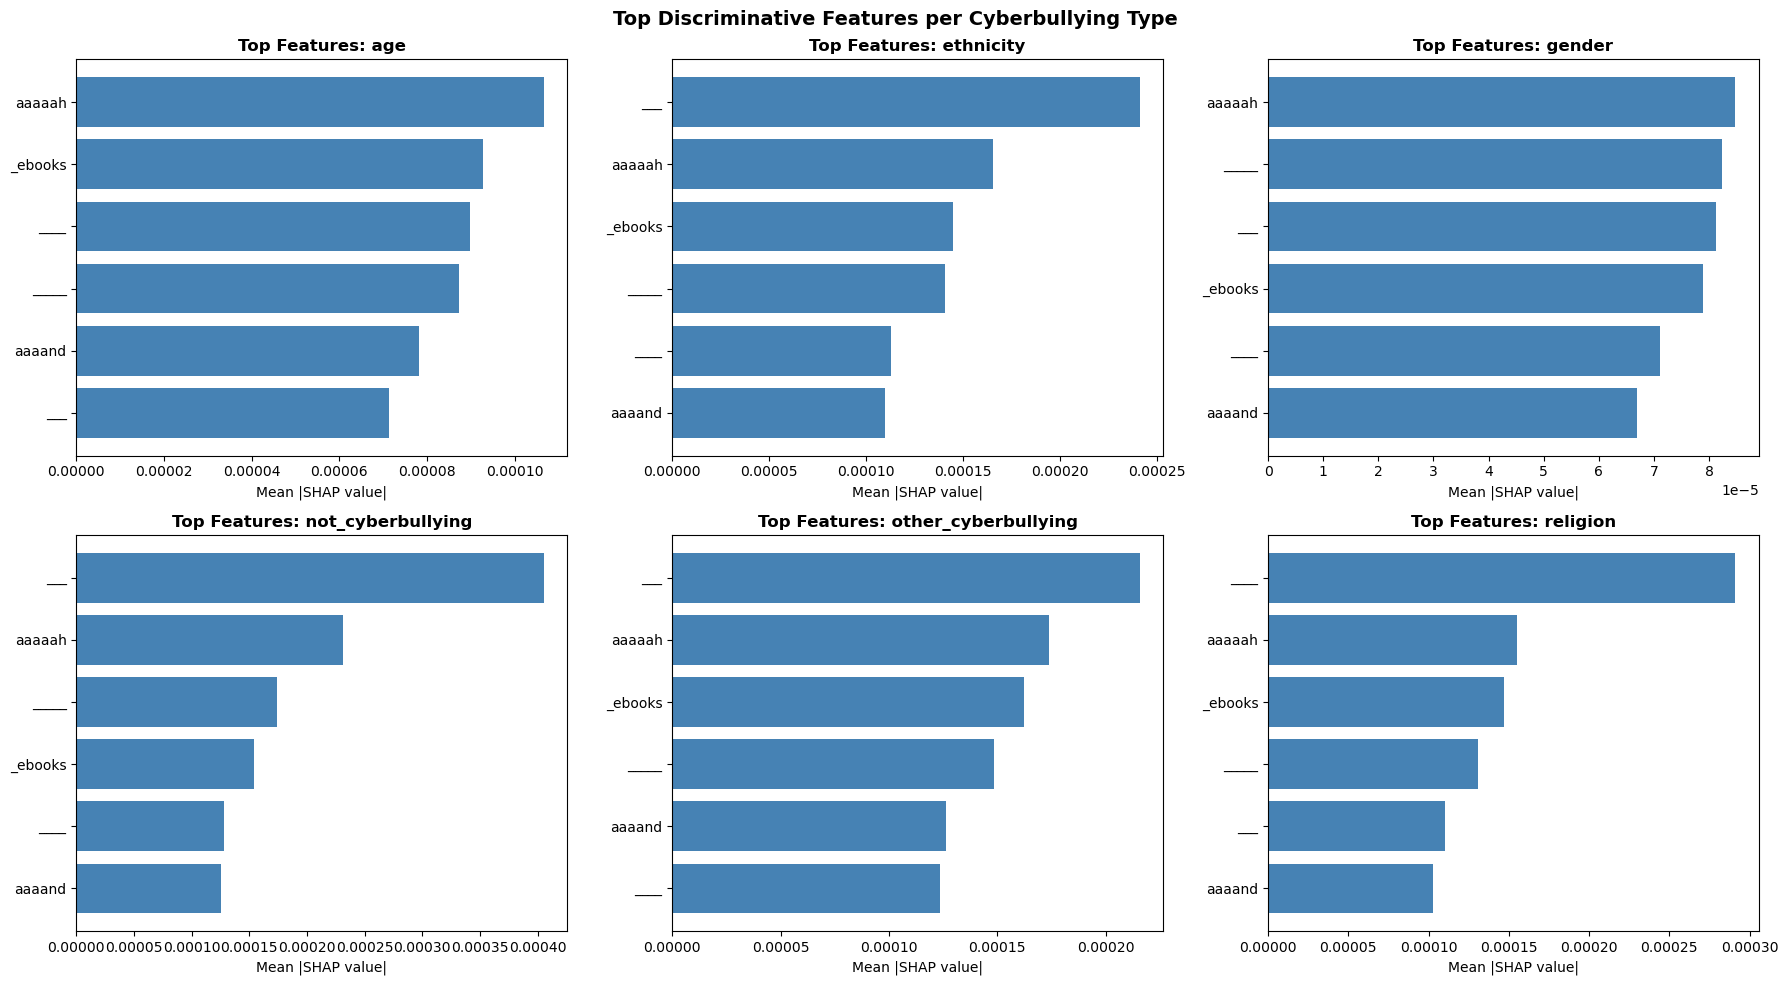

Saved: shap_per_class.png


In [11]:
# Per-class top features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, class_name in enumerate(le.classes_):
    if i >= len(shap_values):
        break
    mean_abs_shap = np.abs(shap_values[i]).mean(axis=0)
    top_idx = np.argsort(mean_abs_shap)[-15:]
    top_features = [feature_names[j] for j in top_idx]
    top_values   = mean_abs_shap[top_idx]

    axes[i].barh(top_features, top_values, color='steelblue')
    axes[i].set_title(f'Top Features: {class_name}', fontweight='bold')
    axes[i].set_xlabel('Mean |SHAP value|')

for j in range(len(le.classes_), len(axes)):
    axes[j].axis('off')

plt.suptitle('Top Discriminative Features per Cyberbullying Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\XPRISTO\Desktop\NLP\shap_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved: shap_per_class.png")

In [12]:
# 2. LIME — LOCAL INSTANCE EXPLANATION
print("\nGenerating LIME explanations...")

lime_explainer = LimeTextExplainer(class_names=list(le.classes_))

def predict_proba(texts):
    """Wrapper for LIME — needs predict_proba."""
    # LinearSVC doesn't have predict_proba natively; use decision_function
    scores = pipeline.decision_function(texts)
    # Convert to probabilities via softmax
    exp    = np.exp(scores - scores.max(axis=1, keepdims=True))
    return exp / exp.sum(axis=1, keepdims=True)


Generating LIME explanations...


In [14]:
# Explain 3 test instances — one from each interesting class
for class_idx, class_name in enumerate(le.classes_[:3]):
    sample_indices = np.where(y_test == class_idx)[0]
    if len(sample_indices) == 0:
        continue
    idx    = sample_indices[0]
    sample = X_test[idx]

    print(f"\nExplaining: '{sample[:80]}...'")
    print(f"True label: {class_name}")

    exp = lime_explainer.explain_instance(
        sample, predict_proba, num_features=10, top_labels=1
    )

    fig = exp.as_pyplot_figure(label=exp.top_labels[0])
    fig.suptitle(f'LIME — {class_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(fr'C:\Users\XPRISTO\Desktop\NLP\lime_{class_name.replace(" ","_")}.png', dpi=150)
    plt.close()
    print(f"Saved: lime_{class_name}.png")

print("\n Explainability step complete.")


Explaining: 'girl hurt bullied best friend high school traumatised life share day post mental...'
True label: age
Saved: lime_age.png

Explaining: 'fuck dumb nigger bass way get stopped stoplight house...'
True label: ethnicity
Saved: lime_ethnicity.png

Explaining: 'kitchen look like theyve reenacted girl cup...'
True label: gender
Saved: lime_gender.png

 Explainability step complete.
